# **Title**

---

# Sleep Efficiency and Lifestyle Analysis using Python

---

### **Objective**

Analyze sleep patterns and lifestyle habits to identify factors affecting sleep efficiency and provide meaningful health insights.

# **Import** **Libraries**

In [ ]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# **Load** **Dataset**

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving sleep_study_1000.csv to sleep_study_1000.csv


In [ ]:
df = pd.read_csv('sleep_study_1000.csv')

In [ ]:
df.head()  # Display First 5 Rows

,ID,Age,Gender,Bedtime,WakeupTime,SleepDuration,SleepEfficiency,REMSleepPercentage,DeepSleepPercentage,LightSleepPercentage,Awakenings,CaffeineConsumption,AlcoholConsumption,SmokingStatus,ExerciseFrequency
0,1,80,Female,2025-09-30 07:32:17,2025-09-30 13:49:16.669051,6.283241,0.57,15,35,50,0,25.0,1,Yes,1
1,2,24,Male,2025-06-29 20:59:50,2025-06-30 04:09:10.207162,7.155613,0.91,29,68,3,4,50.0,0,No,2
2,3,37,Male,2025-12-24 21:28:32,2025-12-25 03:31:34.257053,6.050627,0.58,15,35,50,3,50.0,0,No,5
3,4,68,Female,2025-02-22 00:25:33,2025-02-22 07:26:37.046703,7.017791,0.88,28,44,28,1,50.0,0,Yes,4
4,5,58,Male,2025-09-02 12:31:53,2025-09-02 21:17:46.256228,8.764793,0.95,28,40,32,4,25.0,4,No,4


In [ ]:
df.shape # Dataset Shape

(1000, 15)

In [ ]:
df.columns # Column Names

Index(['ID', 'Age', 'Gender', 'Bedtime', 'WakeupTime', 'SleepDuration',
       'SleepEfficiency', 'REMSleepPercentage', 'DeepSleepPercentage',
       'LightSleepPercentage', 'Awakenings', 'CaffeineConsumption',
       'AlcoholConsumption', 'SmokingStatus', 'ExerciseFrequency'],
      dtype='object')

In [ ]:
df.info() # Dataset Information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    1000 non-null   int64  
 1   Age                   1000 non-null   int64  
 2   Gender                1000 non-null   object 
 3   Bedtime               1000 non-null   object 
 4   WakeupTime            1000 non-null   object 
 5   SleepDuration         1000 non-null   float64
 6   SleepEfficiency       1000 non-null   float64
 7   REMSleepPercentage    1000 non-null   int64  
 8   DeepSleepPercentage   1000 non-null   int64  
 9   LightSleepPercentage  1000 non-null   int64  
 10  Awakenings            1000 non-null   int64  
 11  CaffeineConsumption   744 non-null    float64
 12  AlcoholConsumption    1000 non-null   int64  
 13  SmokingStatus         1000 non-null   object 
 14  ExerciseFrequency     1000 non-null   int64  
dtypes: float64(3), int64(8

In [ ]:
df.describe() # Statistical Summary

,ID,Age,SleepDuration,SleepEfficiency,REMSleepPercentage,DeepSleepPercentage,LightSleepPercentage,Awakenings,CaffeineConsumption,AlcoholConsumption,ExerciseFrequency
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,744.000000,1000.000000,1000.000000
mean,500.500000,50.125000,7.027443,0.720150,22.460000,47.357000,30.183000,2.539000,25.168011,2.560000,2.565000
std,288.819436,18.076397,1.135365,0.128139,4.589059,13.097293,13.788968,1.726691,20.446036,1.746267,1.712515
min,1.000000,18.000000,5.002335,0.500000,15.000000,25.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,250.750000,34.000000,6.076980,0.610000,18.000000,36.000000,18.000000,1.000000,0.000000,1.000000,1.000000
50%,500.500000,51.000000,6.981505,0.720000,22.000000,47.000000,30.000000,3.000000,25.000000,3.000000,3.000000
75%,750.250000,65.000000,8.039587,0.830000,27.000000,59.000000,42.000000,4.000000,50.000000,4.000000,4.000000
max,1000.000000,80.000000,8.998650,0.950000,30.000000,70.000000,59.000000,5.000000,50.000000,5.000000,5.000000


In [ ]:
df.describe(include='object') # Categorical Data Summary

,Gender,Bedtime,WakeupTime,SmokingStatus
count,1000,1000,1000,1000
unique,2,1000,1000,2
top,Male,2025-07-17 14:59:22,2025-07-17 22:48:56.033308,Yes
freq,513,1,1,513


# **Handling Missing Values**

In [ ]:
df.isnull().sum() # Missing Values

,0
ID,0
Age,0
Gender,0
Bedtime,0
WakeupTime,0
SleepDuration,0
SleepEfficiency,0
REMSleepPercentage,0
DeepSleepPercentage,0
LightSleepPercentage,0


In [ ]:
df.duplicated().sum() # Duplicate Values

np.int64(0)

In [ ]:
df['Bedtime'] = pd.to_datetime(df['Bedtime'])
df['WakeupTime'] = pd.to_datetime(df['WakeupTime'])
df # converts the Bedtime and WakeupTime columns from normal
#text format (string/object) into proper datetime format using Pandas

,ID,Age,Gender,Bedtime,WakeupTime,SleepDuration,SleepEfficiency,REMSleepPercentage,DeepSleepPercentage,LightSleepPercentage,Awakenings,CaffeineConsumption,AlcoholConsumption,SmokingStatus,ExerciseFrequency
0,1,80,Female,2025-09-30 07:32:17,2025-09-30 13:49:16.669051,6.283241,0.57,15,35,50,0,25.0,1,Yes,1
1,2,24,Male,2025-06-29 20:59:50,2025-06-30 04:09:10.207162,7.155613,0.91,29,68,3,4,50.0,0,No,2
2,3,37,Male,2025-12-24 21:28:32,2025-12-25 03:31:34.257053,6.050627,0.58,15,35,50,3,50.0,0,No,5
3,4,68,Female,2025-02-22 00:25:33,2025-02-22 07:26:37.046703,7.017791,0.88,28,44,28,1,50.0,0,Yes,4
4,5,58,Male,2025-09-02 12:31:53,2025-09-02 21:17:46.256228,8.764793,0.95,28,40,32,4,25.0,4,No,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,30,Female,2025-05-16 16:24:49,2025-05-16 23:01:38.331733,6.613703,0.92,21,53,26,4,NaN,2,Yes,5
996,997,80,Male,2025-11-11 03:05:18,2025-11-11 09:13:14.413227,6.132337,0.53,16,50,34,3,50.0,3,Yes,3
997,998,77,Female,2025-02-19 03:35:34,2025-02-19 11:50:19.392085,8.245942,0.84,27,58,15,1,NaN,5,No,4
998,999,57,Male,2025-06-28 19:33:34,2025-06-29 01:45:24.810472,6.197447,0.66,29,44,27,4,NaN,1,No,4


#  **Visualization**

In [ ]:
counts, bin_edges = np.histogram(df['SleepEfficiency'], bins=20)
hist_data = pd.DataFrame({'Bin_Start': bin_edges[:-1], 'Bin_End': bin_edges[1:], 'Count': counts})
display(hist_data)

,Bin_Start,Bin_End,Count
0,0.5000,0.5225,63
1,0.5225,0.5450,34
2,0.5450,0.5675,53
3,0.5675,0.5900,40
4,0.5900,0.6125,68
5,0.6125,0.6350,52
6,0.6350,0.6575,50
7,0.6575,0.6800,36
8,0.6800,0.7025,71
9,0.7025,0.7250,44


# **Sleep** **Efficiency** **Distribution**







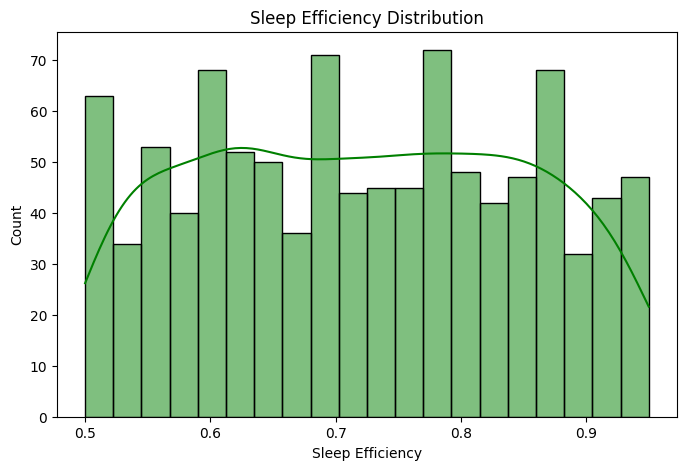

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['SleepEfficiency'],
             bins=20,
             kde=True,
             color='green') # Added color argument

plt.title("Sleep Efficiency Distribution")

plt.xlabel("Sleep Efficiency")

plt.ylabel("Count")

plt.show()

# **.**  Most individuals show moderate to high sleep efficiency levels.

# **Gender** **Wise** **Sleep** **Efficiency**

In [ ]:
gender_sleep_efficiency_stats = df.groupby('Gender')['SleepEfficiency'].describe()
display(gender_sleep_efficiency_stats)

,count,mean,std,min,25%,50%,75%,max
Gender,,,,,,,,
Female,487.0,0.720287,0.123935,0.5,0.62,0.72,0.82,0.95
Male,513.0,0.720019,0.132127,0.5,0.61,0.72,0.84,0.95


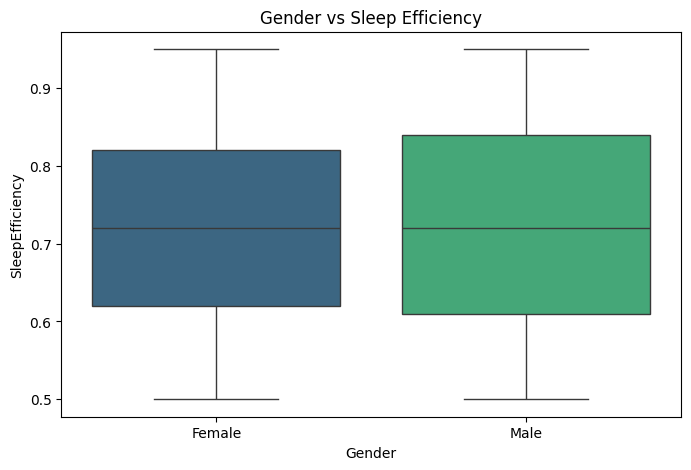

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Gender',
            y='SleepEfficiency',
            data=df,
            palette='viridis') # Added color palette

plt.title("Gender vs Sleep Efficiency")

plt.show()



*   **No Significant Difference**: Both genders show similar median sleep efficiency and comparable spread, suggesting no strong difference in average sleep efficiency.

# **Age** **Distribution**

In [ ]:
counts_age, bin_edges_age = np.histogram(df['Age'], bins=20)
hist_data_age = pd.DataFrame({'Bin_Start': bin_edges_age[:-1], 'Bin_End': bin_edges_age[1:], 'Count': counts_age})
display(hist_data_age)

,Bin_Start,Bin_End,Count
0,18.0,21.1,65
1,21.1,24.2,44
2,24.2,27.3,35
3,27.3,30.4,49
4,30.4,33.5,39
5,33.5,36.6,43
6,36.6,39.7,40
7,39.7,42.8,36
8,42.8,45.9,48
9,45.9,49.0,54


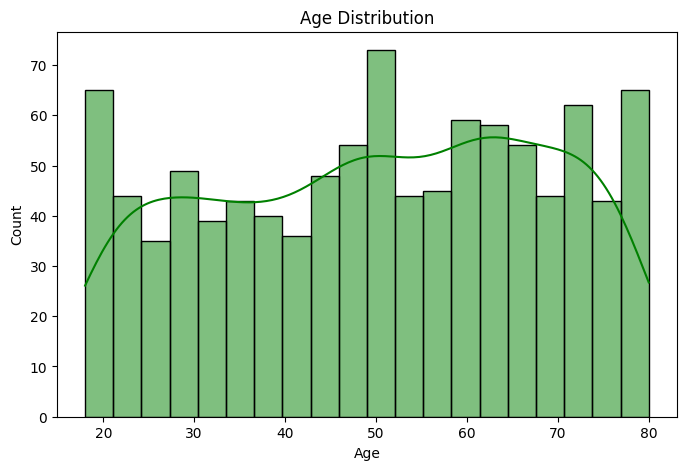

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'],
             bins=20,
             kde=True,
             color='green') # Added color argument

plt.title("Age Distribution")

plt.show()

*   **Diverse Age Range**: The dataset includes a diverse range of ages, indicating a broad demographic representation.

# **Sleep** **Duration** **Analysis**

In [ ]:
display(df[['SleepDuration', 'SleepEfficiency']].head())

,SleepDuration,SleepEfficiency
0,6.283241,0.57
1,7.155613,0.91
2,6.050627,0.58
3,7.017791,0.88
4,8.764793,0.95


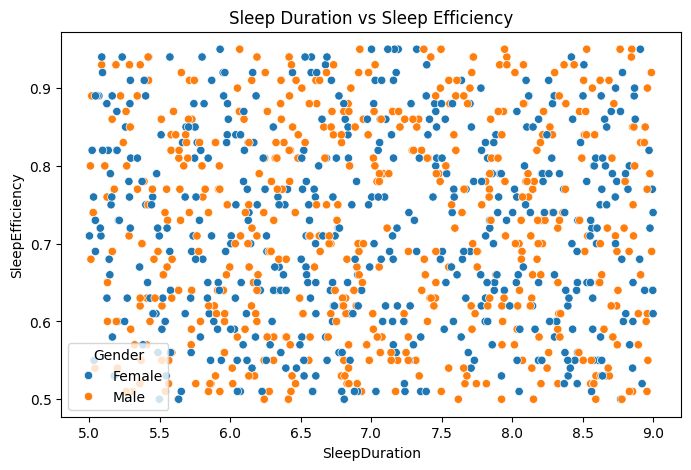

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='SleepDuration',
                y='SleepEfficiency',
                hue='Gender', # Added color based on Gender
                data=df)

plt.title("Sleep Duration vs Sleep Efficiency")

plt.show()

*  Longer sleep duration generally improves sleep efficiency.

# **Caffeine** **Consumption** **Analysis**

In [ ]:
display(df[['CaffeineConsumption_filled', 'SleepEfficiency']].head())

,CaffeineConsumption_filled,SleepEfficiency
0,25.0,0.57
1,50.0,0.91
2,50.0,0.58
3,50.0,0.88
4,25.0,0.95


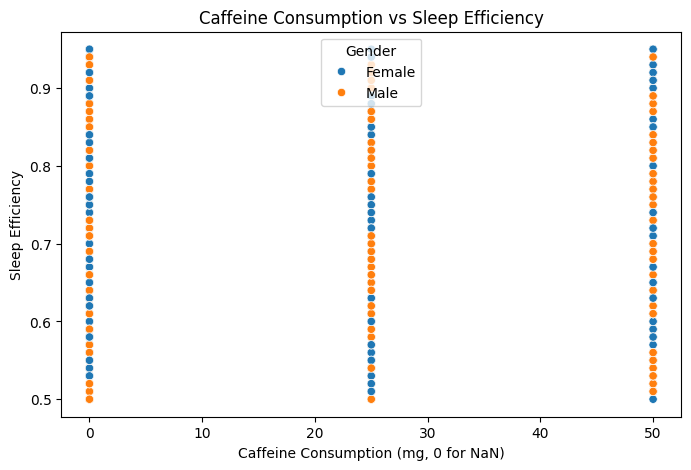

In [ ]:
df['CaffeineConsumption_filled'] = df['CaffeineConsumption'].fillna(0)

plt.figure(figsize=(8,5))
sns.scatterplot(x='CaffeineConsumption_filled',
                y='SleepEfficiency',
                data=df,
                hue='Gender') # Added hue based on Gender
plt.title("Caffeine Consumption vs Sleep Efficiency")
plt.xlabel("Caffeine Consumption (mg, 0 for NaN)")
plt.ylabel("Sleep Efficiency")
plt.show()

  * Higher caffeine consumption may reduce sleep efficiency.

# **Alcohol** **Consumption** **Analysis**

In [ ]:
display(df[['AlcoholConsumption', 'SleepEfficiency']].head())

,AlcoholConsumption,SleepEfficiency
0,1,0.57
1,0,0.91
2,0,0.58
3,0,0.88
4,4,0.95


* Higher alcohol consumption may lead to lower sleep efficiency.

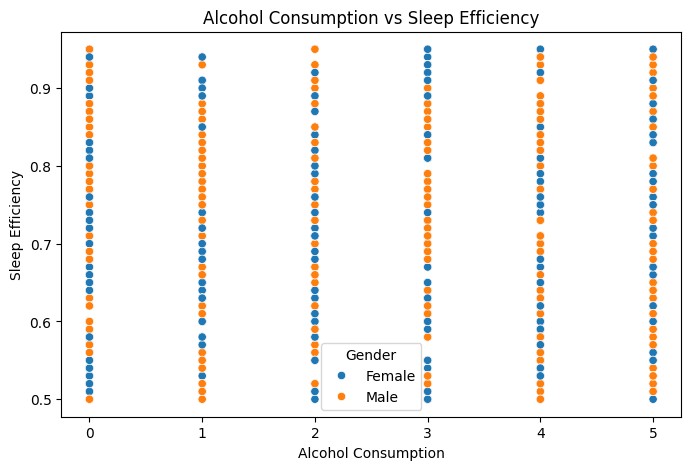

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='AlcoholConsumption',
                y='SleepEfficiency',
                data=df,
                hue='Gender') # Added hue based on Gender
plt.title("Alcohol Consumption vs Sleep Efficiency")
plt.xlabel("Alcohol Consumption")
plt.ylabel("Sleep Efficiency")
plt.show()

# **Smoking** **Status** **Analysis**

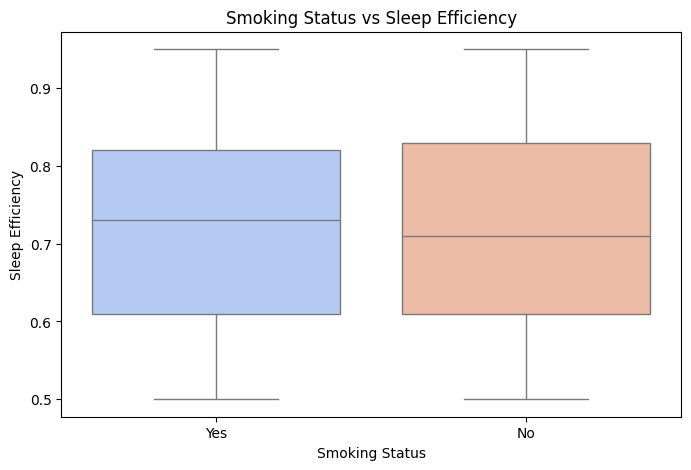

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='SmokingStatus',
            y='SleepEfficiency',
            data=df,
            palette='coolwarm') # Added a color palette
plt.title("Smoking Status vs Sleep Efficiency")
plt.xlabel("Smoking Status")
plt.ylabel("Sleep Efficiency")
plt.show()

In [ ]:
smoking_sleep_efficiency_stats = df.groupby('SmokingStatus')['SleepEfficiency'].describe()
display(smoking_sleep_efficiency_stats)

,count,mean,std,min,25%,50%,75%,max
SmokingStatus,,,,,,,,
No,487.0,0.717864,0.129615,0.5,0.61,0.71,0.83,0.95
Yes,513.0,0.722320,0.126811,0.5,0.61,0.73,0.82,0.95


 *   **No Significant Difference**: The descriptive statistics indicate no strong difference in sleep efficiency between individuals who smoke and those who don't.

# **Exercise** **Frequency** **Analysis**

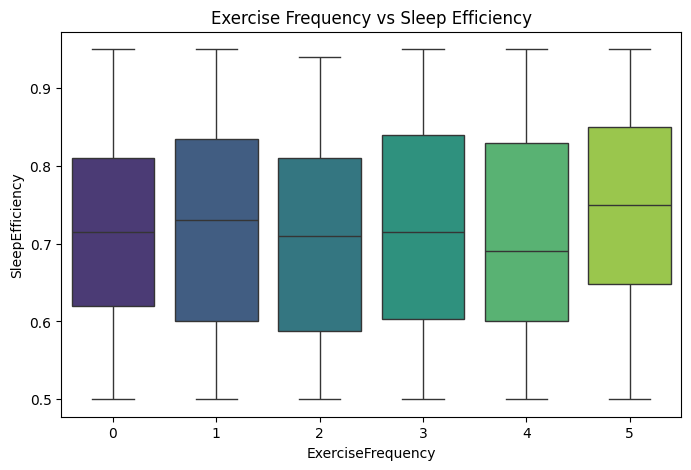

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='ExerciseFrequency',
            y='SleepEfficiency',
            data=df,
            palette='viridis') # Added color palette
plt.title("Exercise Frequency vs Sleep Efficiency")
plt.show()

In [ ]:
exercise_sleep_efficiency_stats = df.groupby('ExerciseFrequency')['SleepEfficiency'].describe()
display(exercise_sleep_efficiency_stats)

,count,mean,std,min,25%,50%,75%,max
ExerciseFrequency,,,,,,,,
0,172.0,0.720349,0.123879,0.5,0.6200,0.715,0.810,0.95
1,143.0,0.720000,0.128452,0.5,0.6000,0.730,0.835,0.95
2,152.0,0.705197,0.127705,0.5,0.5875,0.710,0.810,0.94
3,178.0,0.721910,0.136186,0.5,0.6025,0.715,0.840,0.95
4,191.0,0.709005,0.129031,0.5,0.6000,0.690,0.830,0.95
5,164.0,0.745000,0.120528,0.5,0.6475,0.750,0.850,0.95


*   **Positive Correlation**: Individuals with higher exercise frequency tend to have higher sleep efficiency, indicating a positive relationship between exercise and sleep quality.

# **Correlation** **Heatmap**

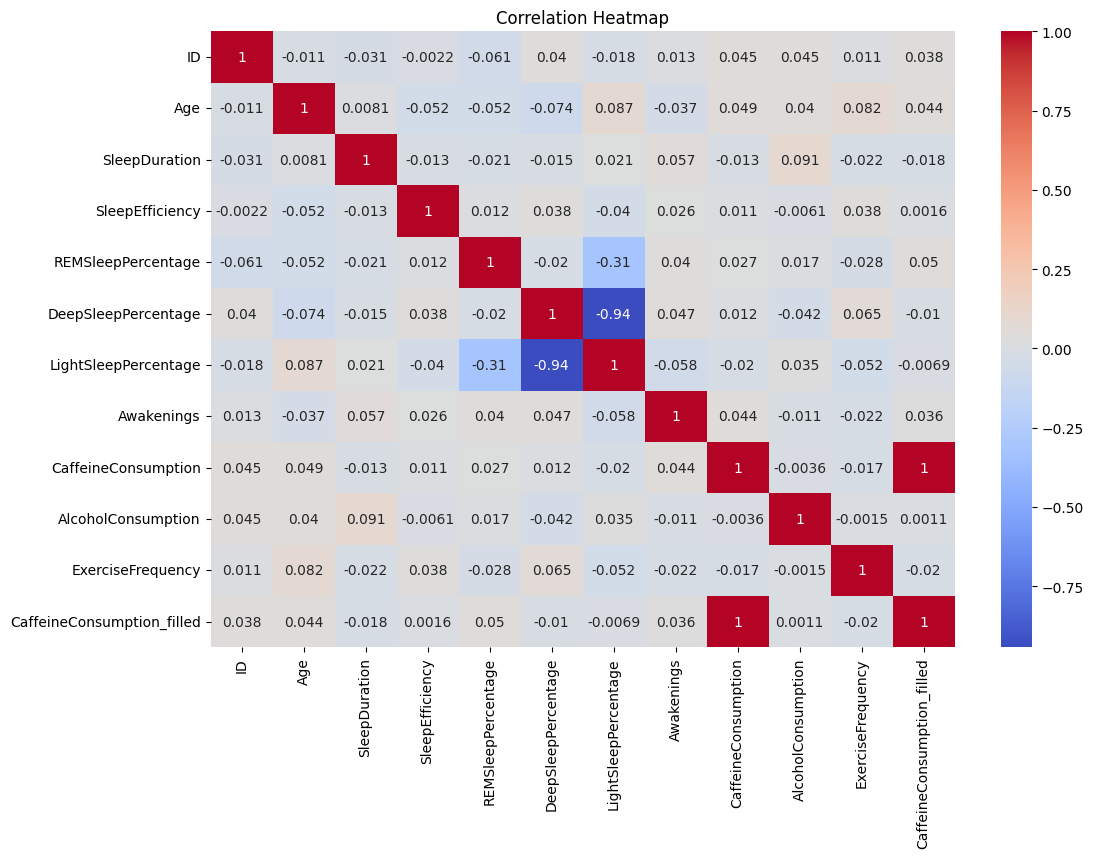

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
correlation_matrix = df.corr(numeric_only=True)
display(correlation_matrix)

,ID,Age,SleepDuration,SleepEfficiency,REMSleepPercentage,DeepSleepPercentage,LightSleepPercentage,Awakenings,CaffeineConsumption,AlcoholConsumption,ExerciseFrequency,CaffeineConsumption_filled
ID,1.000000,-0.010553,-0.030703,-0.002161,-0.061298,0.040221,-0.017803,0.012618,0.044599,0.044702,0.011375,0.038098
Age,-0.010553,1.000000,0.008055,-0.052316,-0.051544,-0.073626,0.087087,-0.037406,0.048838,0.040463,0.081726,0.044202
SleepDuration,-0.030703,0.008055,1.000000,-0.013127,-0.021359,-0.014613,0.020988,0.056650,-0.013195,0.091232,-0.021906,-0.017591
SleepEfficiency,-0.002161,-0.052316,-0.013127,1.000000,0.011986,0.038039,-0.040120,0.025920,0.010674,-0.006147,0.037566,0.001576
REMSleepPercentage,-0.061298,-0.051544,-0.021359,0.011986,1.000000,-0.020489,-0.313346,0.040432,0.027105,0.016788,-0.027882,0.049989
DeepSleepPercentage,0.040221,-0.073626,-0.014613,0.038039,-0.020489,1.000000,-0.943020,0.046546,0.011665,-0.042406,0.064993,-0.010244
LightSleepPercentage,-0.017803,0.087087,0.020988,-0.040120,-0.313346,-0.943020,1.000000,-0.057667,-0.020180,0.034692,-0.052454,-0.006906
Awakenings,0.012618,-0.037406,0.056650,0.025920,0.040432,0.046546,-0.057667,1.000000,0.044288,-0.011234,-0.022185,0.035777
CaffeineConsumption,0.044599,0.048838,-0.013195,0.010674,0.027105,0.011665,-0.020180,0.044288,1.000000,-0.003647,-0.017058,1.000000
AlcoholConsumption,0.044702,0.040463,0.091232,-0.006147,0.016788,-0.042406,0.034692,-0.011234,-0.003647,1.000000,-0.001473,0.001076


*   The heatmap shows a strong inverse correlation between Deep Sleep Percentage and Light Sleep Percentage.

# **All** **Variable** **Relationship**

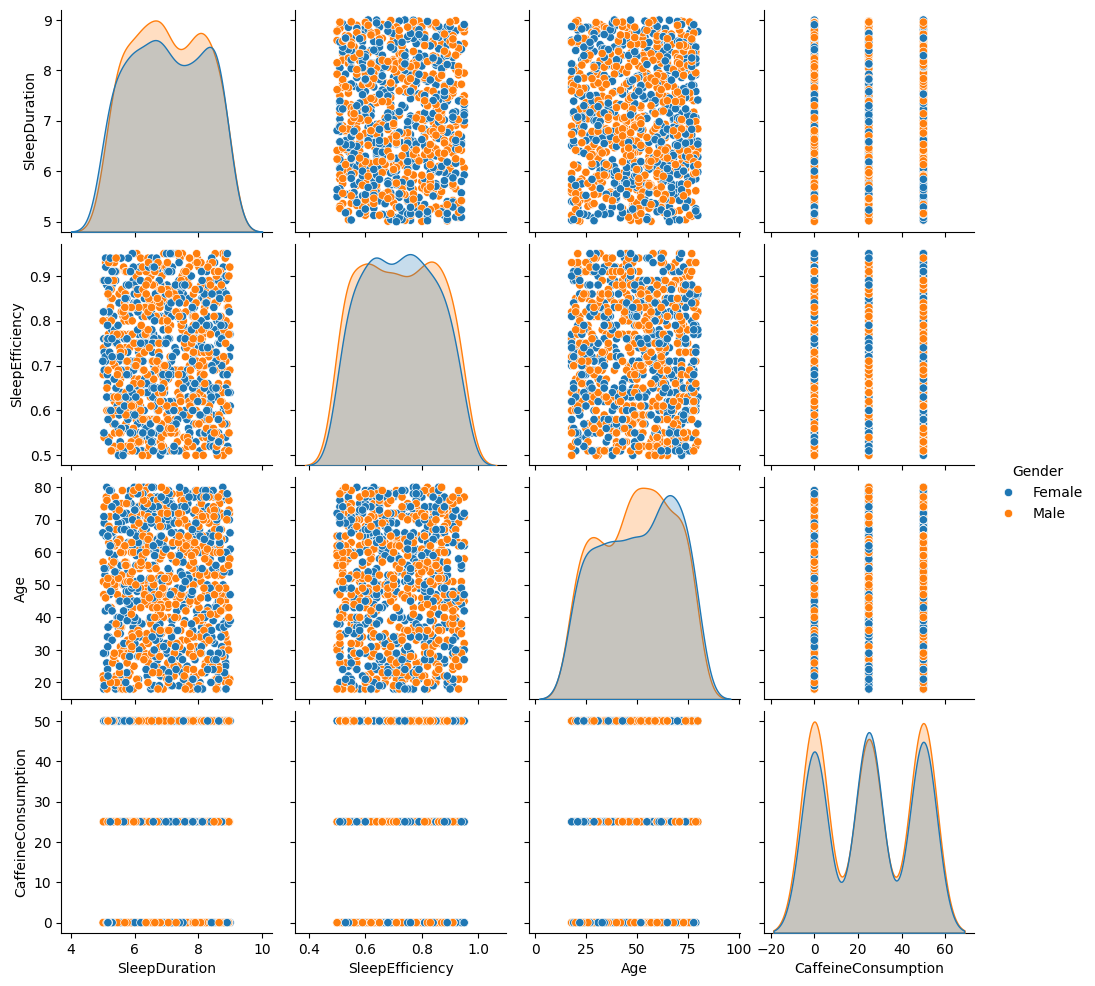

In [ ]:
sns.pairplot(df[['SleepDuration','SleepEfficiency','Age','CaffeineConsumption', 'Gender']], hue='Gender')
plt.show()   # All variable relationships


# **.** Visualizing relationships between important numerical variables.

# **Key Insights**

1. Sleep duration positively affects sleep efficiency.

2. High caffeine and alcohol consumption may reduce sleep quality.

3. Regular exercise supports better sleep efficiency.

4. Smoking habits may negatively impact sleep patterns.

5. Lifestyle habits significantly influence sleep health.

# **Business** **Impact**

This analysis highlights how lifestyle habits and daily routines directly influence sleep efficiency and overall wellness. The findings from the project can support healthcare professionals, wellness organizations, fitness platforms, and employers in promoting healthier sleep behaviors and improving quality of life.

### **Key** **Business Impact Areas**

- Identified the relationship between sleep duration and sleep efficiency, helping understand healthy sleep patterns.

- Revealed that higher caffeine and alcohol consumption may negatively impact sleep quality and recovery.

- Showed that regular exercise frequency is associated with better sleep efficiency and healthier lifestyle outcomes.

- Demonstrated how smoking habits can affect sleep performance and overall wellness indicators.

- Enabled data-driven insights that can support wellness monitoring, preventive healthcare strategies, and personalized lifestyle recommendations.

### **Real-World Applications**

- Healthcare & Wellness Analytics  
- Employee Wellness Programs  
- Fitness & Lifestyle Tracking Applications  
- Sleep Monitoring Platforms  
- Preventive Healthcare Research  

### **Overall Impact**

This project demonstrates how data analytics can be used to uncover meaningful health patterns, improve lifestyle awareness, and support data-driven decision-making in healthcare and wellness industries.

# **Conclusion**
This project revealed how lifestyle habits such as sleep duration, caffeine intake, alcohol consumption, smoking, and exercise frequency significantly influence sleep efficiency. The analysis demonstrates the power of data analytics in identifying meaningful health patterns and supporting healthier lifestyle decisions.

**Author**
Jyotirmaya Mishra